In [16]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches

[0.435175, 2.051467, 0.453962, 2.052648]


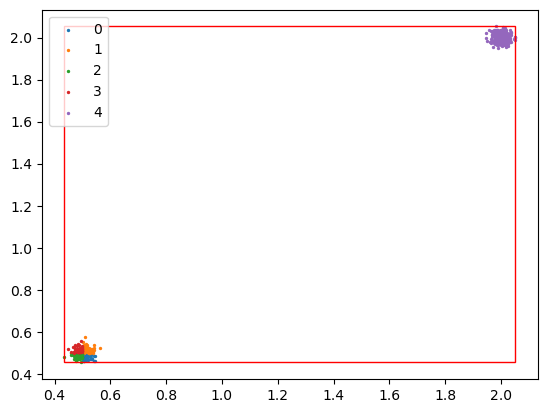

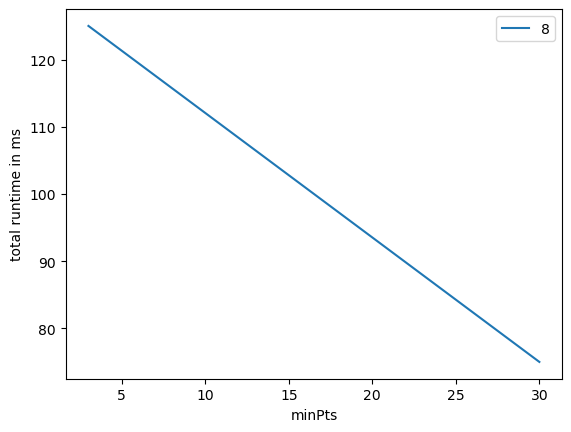

/tmp/ipykernel_11990/1151033159.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


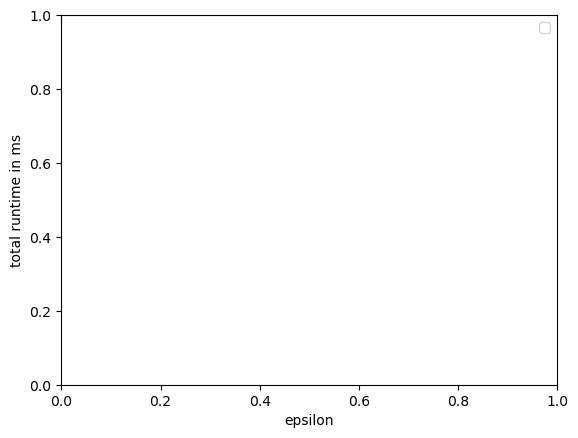

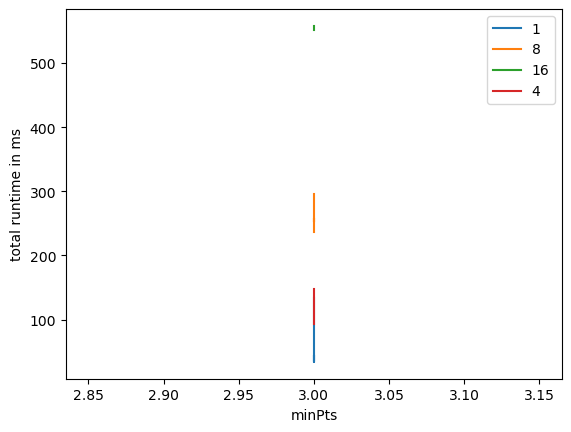

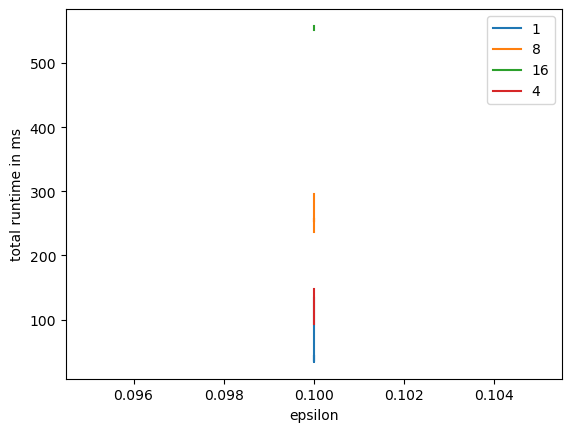

In [17]:
points_name = "points.csv"
timing_name = "timing.csv"
bounding_name = "bounding.csv"
save_directory = "results/"

Path(save_directory).mkdir(exist_ok=True)

points_df = pd.read_csv(points_name)
timing_df = pd.read_csv(timing_name)
xmin = points_df["x0"].min()
xmax = points_df["x0"].max()
ymin = points_df["x1"].min()
ymax = points_df["x1"].max()

bbs_df = pd.read_csv(bounding_name)
bbs = []

for temp_x_min in bbs_df["x0min"]:
    if temp_x_min == "min_x0":
        temp_x_min = xmin
    bbs.append([float(temp_x_min)])

count = 0
for temp_x_max in bbs_df["x0max"]:
    if temp_x_max == "max_x0":
        temp_x_max = xmax
    bbs[count].append(float(temp_x_max))
    count += 1

count = 0
for temp_y_min in bbs_df["x1min"]:
    if temp_y_min == "min_x1":
        temp_y_min = ymin
    bbs[count].append(float(temp_y_min))
    count += 1

count = 0
for temp_y_max in bbs_df["x1max"]:
    if temp_y_max == "max_x1":
        temp_y_max = ymax
    bbs[count].append(float(temp_y_max))
    count += 1

#print(bbs)
for bb in bbs:
    print(bb)

fig,ax = plt.subplots()
for cluster in points_df["clusterId"].unique():
    cluster_df = points_df[points_df["clusterId"] == cluster]
    ax.scatter(cluster_df["x0"], cluster_df["x1"], s=2, label=str(cluster))
for bb in bbs:
    x1 = bb[0]
    x2 = bb[1]
    y1 = bb[2]
    y2 = bb[3]
    width = x2-x1
    height = y2-y1
    rect = patches.Rectangle(
        (x1, y1), width, height,
        linewidth=1,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)
plt.legend()
plt.show()

for dataset in timing_df["dataset"].unique():
    timing_dataset_df = timing_df[timing_df["dataset"] == dataset]
    for epsilon in timing_dataset_df["epsilon"].unique():
        timing_dataset_epsilon_df = timing_dataset_df[timing_dataset_df["epsilon"] == epsilon].sort_values(by="minPts")
        if (not timing_dataset_epsilon_df.empty) and len(timing_dataset_epsilon_df) > 1:
            for num_of_processes in timing_dataset_epsilon_df["numProcesses"].unique():
                timing_dataset_epsilon_nump_df = timing_dataset_epsilon_df[timing_dataset_epsilon_df["numProcesses"] == num_of_processes]
                if (not timing_dataset_epsilon_nump_df.empty) and len(timing_dataset_epsilon_nump_df) > 1:
                    plt.plot(timing_dataset_epsilon_nump_df["minPts"], timing_dataset_epsilon_nump_df["totalMs"], label=str(num_of_processes))
            plt.xlabel("minPts")
            plt.ylabel("total runtime in ms")
            plt.legend()
            plt.show()
    for minPts in timing_dataset_df["minPts"].unique():
        timing_dataset_minpts_df = timing_dataset_df[timing_dataset_df["minPts"] == minPts].sort_values(by="epsilon")
        if (not timing_dataset_minpts_df.empty) and len(timing_dataset_minpts_df) > 1:
            for num_of_processes in timing_dataset_minpts_df["numProcesses"].unique():
                timing_dataset_minpts_nump_df = timing_dataset_minpts_df[timing_dataset_minpts_df["numProcesses"] == num_of_processes]
                if (not timing_dataset_minpts_nump_df.empty) and len(timing_dataset_minpts_nump_df) > 1:
                    plt.plot(timing_dataset_minpts_nump_df["epsilon"], timing_dataset_minpts_nump_df["totalMs"], label=str(num_of_processes))
            plt.xlabel("epsilon")
            plt.ylabel("total runtime in ms")
            plt.legend()
            plt.show()